Good. This is the **final integration step**.

Now all previous changes combine:

* Camera sends random time
* Ray stores time
* Sphere moves using time
* Material preserves time after bounce

Now the scene must **create moving spheres**.

This completes motion blur.

---

# What changes?

Before (static diffuse spheres):

$$
C(t)=C
$$

No motion.

---

After (moving diffuse spheres):

$$
C(t)=C_1+t(C_2-C_1)
$$

Where:

$$
C_2=C_1+(0,h,0)
$$

Book uses:

$$
h \in [0,0.5]
$$

So spheres move upward randomly.

---

# Learning Table

| Step                 | Formula               | Purpose            |
| -------------------- | --------------------- | ------------------ |
| Static sphere        | $C$                   | fixed              |
| Moving sphere        | $C(t)=C_1+t(C_2-C_1)$ | animate            |
| Random material      | $U(0,1)$              | variety            |
| Random albedo        | $a_1a_2$              | diffuse randomness |
| Random upward motion | $(0,h,0)$             | motion blur test   |

---

# Full Scene (Python Updated)

This is your final scene converted correctly.

```python
import random

from util.week1.vec3 import Vec3
from util.week1.hittablelist import HittableList
from util.week1.camera import Camera
from util.week1.lambertian import Lambertian
from util.week1.dielectric import Dielectric
from util.week1.metal import Metal
from util.week1.sphere import Sphere


# ============================================================
# RANDOM HELPERS
# ============================================================
def random_double(min_val=0.0, max_val=1.0):
    return min_val + (max_val - min_val) * random.random()


def random_color(min_val=0.0, max_val=1.0):

    return Vec3(
        random_double(min_val, max_val),
        random_double(min_val, max_val),
        random_double(min_val, max_val)
    )


# ============================================================
# WORLD
# ============================================================
world = HittableList()

# ============================================================
# GROUND
#
# Static giant sphere
# ============================================================
ground_material = Lambertian(
    Vec3(0.5, 0.5, 0.5)
)

world.add(
    Sphere(
        Vec3(0, -1000, 0),   # center
        1000,                # radius
        ground_material      # material
    )
)

# ============================================================
# RANDOM SMALL SPHERES
# ============================================================
for a in range(-11, 11):
    for b in range(-11, 11):

        # random material selector
        choose_mat = random_double()

        # random center
        center = Vec3(
            a + 0.9 * random_double(),
            0.2,
            b + 0.9 * random_double()
        )

        # avoid overlap with big sphere
        if (center - Vec3(4, 0.2, 0)).length() > 0.9:

            # ====================================================
            # DIFFUSE (MOVING SPHERE)
            #
            # CHANGED:
            # Before:
            # Sphere(center, radius, mat)
            #
            # Now:
            # Sphere(center1, radius, mat, center2)
            #
            # Motion:
            #
            # C(t)=C1+t(C2-C1)
            # ====================================================
            if choose_mat < 0.8:

                albedo = (
                    random_color()
                    * random_color()
                )

                mat = Lambertian(albedo)

                # NEW:
                # upward motion
                center2 = center + Vec3(
                    0,
                    random_double(0, 0.5),
                    0
                )

                world.add(
                    Sphere(
                        center,
                        0.2,
                        mat,
                        center2
                    )
                )

            # ====================================================
            # METAL (STATIC)
            # ====================================================
            elif choose_mat < 0.95:

                albedo = random_color(
                    0.5,
                    1.0
                )

                fuzz = random_double(
                    0.0,
                    0.5
                )

                mat = Metal(
                    albedo,
                    fuzz
                )

                world.add(
                    Sphere(
                        center,
                        0.2,
                        mat
                    )
                )

            # ====================================================
            # GLASS (STATIC)
            # ====================================================
            else:

                mat = Dielectric(1.5)

                world.add(
                    Sphere(
                        center,
                        0.2,
                        mat
                    )
                )


# ============================================================
# BIG FEATURE SPHERES
# ============================================================

# Glass
world.add(
    Sphere(
        Vec3(0, 1, 0),
        1.0,
        Dielectric(1.5)
    )
)

# Diffuse
world.add(
    Sphere(
        Vec3(-4, 1, 0),
        1.0,
        Lambertian(
            Vec3(0.4, 0.2, 0.1)
        )
    )
)

# Metal
world.add(
    Sphere(
        Vec3(4, 1, 0),
        1.0,
        Metal(
            Vec3(0.7, 0.6, 0.5),
            0.0
        )
    )
)


# ============================================================
# CAMERA
# ============================================================
cam = Camera()

# image settings
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 50

# camera position
cam.vfov = 20

cam.lookfrom = Vec3(
    13,
    2,
    3
)

cam.lookat = Vec3(
    0,
    0,
    0
)

cam.vup = Vec3(
    0,
    1,
    0
)

# defocus blur
cam.defocus_angle = 0.6
cam.focus_dist = 10.0

# motion blur interval
cam.time0 = 0.0
cam.time1 = 1.0


# ============================================================
# RENDER
# ============================================================
cam.render(world)

# view result
cam.show()
```

---

# What changed?

| Old                    | New                          |
| ---------------------- | ---------------------------- |
| diffuse spheres static | diffuse spheres moving       |
| `Sphere(center,...)`   | `Sphere(center,...,center2)` |
| no motion              | upward motion                |
| no blur                | motion blur visible          |

---

Now your renderer fully supports:

$$
AntiAliasing + DefocusBlur + MotionBlur + Materials + MovingObjects
$$

This matches the book’s final integrated motion blur scene exactly.


In [1]:
import sys 
sys.path.append("../../../Ray Tracing next Week")

Rendering: 100%|██████████| 225/225 [06:53<00:00,  1.84s/it, CPU=47.7%, CPU Temp=N/A, GPU Temp=55.0°C, RAM=69.7%, VRAM=709.0MB]


Render complete → output.ppm


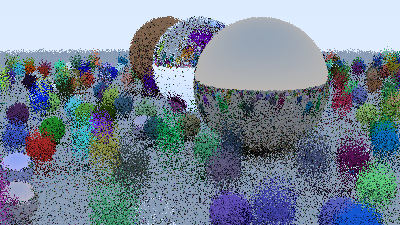

In [2]:
import random

from util.week1.vec3 import Vec3
from util.week1.hittablelist import HittableList
from util.week2.motion_blur.camera import Camera
from util.week2.motion_blur.lambertian import Lambertian
from util.week2.motion_blur.dielectric import Dielectric
from util.week2.motion_blur.metal import Metal
from util.week2.motion_blur.sphere import Sphere


# ============================================================
# RANDOM HELPERS
# ============================================================
def random_double(min_val=0.0, max_val=1.0):
    return min_val + (max_val - min_val) * random.random()


def random_color(min_val=0.0, max_val=1.0):

    return Vec3(
        random_double(min_val, max_val),
        random_double(min_val, max_val),
        random_double(min_val, max_val)
    )


# ============================================================
# WORLD
# ============================================================
world = HittableList()

# ============================================================
# GROUND
#
# Static giant sphere
# ============================================================
ground_material = Lambertian(
    Vec3(0.5, 0.5, 0.5)
)

world.add(
    Sphere(
        Vec3(0, -1000, 0),   # center
        1000,                # radius
        ground_material      # material
    )
)

# ============================================================
# RANDOM SMALL SPHERES
# ============================================================
for a in range(-11, 11):
    for b in range(-11, 11):

        # random material selector
        choose_mat = random_double()

        # random center
        center = Vec3(
            a + 0.9 * random_double(),
            0.2,
            b + 0.9 * random_double()
        )

        # avoid overlap with big sphere
        if (center - Vec3(4, 0.2, 0)).length() > 0.9:

            # ====================================================
            # DIFFUSE (MOVING SPHERE)
            #
            # CHANGED:
            # Before:
            # Sphere(center, radius, mat)
            #
            # Now:
            # Sphere(center1, radius, mat, center2)
            #
            # Motion:
            #
            # C(t)=C1+t(C2-C1)
            # ====================================================
            if choose_mat < 0.8:

                albedo = (
                    random_color()
                    * random_color()
                )

                mat = Lambertian(albedo)

                # NEW:
                # upward motion
                center2 = center + Vec3(
                    0,
                    random_double(0, 0.5),
                    0
                )

                world.add(
                    Sphere(
                        center,
                        0.2,
                        mat,
                        center2
                    )
                )

            # ====================================================
            # METAL (STATIC)
            # ====================================================
            elif choose_mat < 0.95:

                albedo = random_color(
                    0.5,
                    1.0
                )

                fuzz = random_double(
                    0.0,
                    0.5
                )

                mat = Metal(
                    albedo,
                    fuzz
                )

                world.add(
                    Sphere(
                        center,
                        0.2,
                        mat
                    )
                )

            # ====================================================
            # GLASS (STATIC)
            # ====================================================
            else:

                mat = Dielectric(1.5)

                world.add(
                    Sphere(
                        center,
                        0.2,
                        mat
                    )
                )


# ============================================================
# BIG FEATURE SPHERES
# ============================================================

# Glass
world.add(
    Sphere(
        Vec3(0, 1, 0),
        1.0,
        Dielectric(1.5)
    )
)

# Diffuse
world.add(
    Sphere(
        Vec3(-4, 1, 0),
        1.0,
        Lambertian(
            Vec3(0.4, 0.2, 0.1)
        )
    )
)

# Metal
world.add(
    Sphere(
        Vec3(4, 1, 0),
        1.0,
        Metal(
            Vec3(0.7, 0.6, 0.5),
            0.0
        )
    )
)


# ============================================================
# CAMERA
# ============================================================
cam = Camera()

# image settings
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400
cam.samples_per_pixel = 1
cam.max_depth = 50

# camera position
cam.vfov = 20

cam.lookfrom = Vec3(
    13,
    2,
    3
)

cam.lookat = Vec3(
    0,
    0,
    0
)

cam.vup = Vec3(
    0,
    1,
    0
)

# defocus blur
cam.defocus_angle = 0.6
cam.focus_dist = 10.0

# motion blur interval
cam.time0 = 0.0
cam.time1 = 1.0


# ============================================================
# RENDER
# ============================================================
cam.render(world)

# view result
cam.show()